In [4]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
train_merged = pd.read_csv("../outputs/train_fe.csv")
train_merged["date"] = pd.to_datetime(train_merged["date"])
split_date = train_merged["date"].quantile(0.8)
train_part = train_merged[train_merged["date"] < split_date].copy()
test_part = train_merged[train_merged["date"] >= split_date].copy()

In [6]:
sequence_features = [
  "lag_sales",
  "onpromotion" ,
  "dcoilwtico",
  "is_weekend",
  "holiday_national_binary",
  "is_black_friday",
  "is_cyber_monday",
  "is_mothers_day",
  "is_earthquake",
  "is_world_cup"
]

In [ ]:
train_merged = train_part[
    train_part["store_nbr"].isin([1, 2, 3, 4, 5, 12])
].copy()
test_part_big = test_part[
    test_part["store_nbr"].isin([1, 2, 3, 4, 5, 12])
].copy()

In [ ]:
train_merged["lag_sales"] = train_merged.groupby(["store_nbr", "family"])["sales"].shift(1)
test_part_big["lag_sales"] = test_part_big.groupby(["store_nbr", "family"])["sales"].shift(1)

train_merged[sequence_features] = train_merged[sequence_features].replace([np.inf, -np.inf], 0)
test_part_big[sequence_features] = test_part_big[sequence_features].replace([np.inf, -np.inf], 0)

train_merged[sequence_features] = train_merged[sequence_features].fillna(0)
test_part_big[sequence_features] = test_part_big[sequence_features].fillna(0)


In [9]:
def create_sequence(df, feature_cols, target_cols="sales",window=14): 
    X_seq= []
    y_seq = []
    df = df.sort_values(["store_nbr", "family", "date"]) 
    meta_rows= []

    for(store, family), group in df.groupby(["store_nbr", "family"]):
      group = group.sort_values("date")
      group = group.dropna()

      values = group[feature_cols].values 
      target = group[target_cols].values 

      if len(group) <= window:
          continue

      values= group[feature_cols].values
      target = group[target_cols].values

      for i in range(window, len(group)):
          X_seq.append(values[i-window:i]) 
          y_seq.append(target[i]) 

          meta_rows.append({
              "store_nbr": store,
              "family" : family,
              "date": group.iloc[i]["date"],
              "onpromotion_target" : group.iloc[i]["onpromotion"],
              "promo_flag" : int(group.iloc[i]["onpromotion"] > 0)
          })
    X_seq = np.array(X_seq, dtype= np.float32)
    y_seq = np.array(y_seq)
    meta_df = pd.DataFrame(meta_rows)

    return X_seq, y_seq, meta_df


In [ ]:
X_train_seq, y_train_seq, meta_train = create_sequence(
    train_merged[["store_nbr", "family", "date", "sales"] + sequence_features].copy(),
    feature_cols= sequence_features,
    target_cols = "sales",
    window= 14
)

X_test_seq, y_test_seq, meta_test = create_sequence(
     test_part_big[["store_nbr", "family", "date", "sales"] + sequence_features].copy(),
     feature_cols= sequence_features,
     target_cols = "sales",
     window= 14
)

In [11]:
print("X_train_seq shape: ", X_train_seq.shape)
print("y_train_seq shape: ", y_train_seq.shape)
print("X_test_seq shape: ", X_test_seq.shape)
print("y_test_seq shape: ", y_test_seq.shape)
print("meta_train shape: ", meta_train.shape)
print("meta_test shape: ", meta_test.shape)

X_train_seq shape:  (263934, 14, 10)
y_train_seq shape:  (263934,)
X_test_seq shape:  (63954, 14, 10)
y_test_seq shape:  (63954,)
meta_train shape:  (263934, 5)
meta_test shape:  (63954, 5)


In [12]:
seq_scaler = StandardScaler() 
n_train, window_size, n_features = X_train_seq.shape 
n_test = X_test_seq.shape[0]

X_train_seq_2d = X_train_seq.reshape(-1, n_features) 
X_test_seq_2d = X_test_seq.reshape(-1, n_features)

X_train_seq_scaled = seq_scaler.fit_transform(X_train_seq_2d).astype(np.float32).reshape(n_train, window_size, n_features)
X_test_seq_scaled = seq_scaler.transform(X_test_seq_2d).astype(np.float32).reshape(n_test, window_size, n_features)


In [13]:
print("Scaled train shape: ", X_train_seq_scaled.shape)
print("Scaled test shape: ", X_test_seq_scaled.shape)
print("NaN train seq: ", np.isnan(X_train_seq_scaled).sum())
print("NaN test seq: ", np.isnan(X_test_seq_scaled).sum())

Scaled train shape:  (263934, 14, 10)
Scaled test shape:  (63954, 14, 10)
NaN train seq:  0
NaN test seq:  0


In [14]:
del X_train_seq_2d, X_test_seq_2d
gc.collect()

lstm_model = keras.Sequential([
    layers.Input(shape=(X_train_seq_scaled.shape[1], X_train_seq_scaled.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)
])

In [15]:
lstm_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop_lstm= keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

In [17]:
history_lstm = lstm_model.fit(
    X_train_seq_scaled,
    y_train_seq,
    validation_split= 0.1,
    epochs =10,
    batch_size = 128,
    callbacks= [early_stop_lstm],
    verbose= 1
)


Epoch 1/10
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 1004709.2500 - mae: 261.4749 - val_loss: 1316.6400 - val_mae: 14.5709
Epoch 2/10
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - loss: 370951.1562 - mae: 120.6124 - val_loss: 1225.3820 - val_mae: 16.0600
Epoch 3/10
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 202247.7188 - mae: 94.0993 - val_loss: 1545.9449 - val_mae: 25.5649
Epoch 4/10
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 167283.8750 - mae: 87.5340 - val_loss: 1609.8824 - val_mae: 19.7783
Epoch 5/10
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 158244.6562 - mae: 84.6536 - val_loss: 1296.0878 - val_mae: 19.4078


In [25]:
def safe_mape(y_true, y_pred,eps=1e-8): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = np.abs(y_true) > eps 
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))*100

In [19]:
lstm_preds = lstm_model.predict(X_test_seq_scaled, batch_size = 256).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_preds))
lstm_mae = mean_absolute_error(y_test_seq, lstm_preds)
lstm_mape = safe_mape(y_test_seq, lstm_preds)
print("LSTM RMSE: ", lstm_rmse)
print("LSTM MAE: ", lstm_mae)
print("LSTM MAPE: ", lstm_mape)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
LSTM RMSE:  549.0900616357115
LSTM MAE:  119.95434837877886
LSTM MAPE:  75.08017041957501


In [20]:
results_df = meta_test.copy()
results_df["y_true"] = y_test_seq
results_df["y_preds"] = lstm_preds
results_df["residual"] = results_df["y_true"] - results_df["y_preds"]
results_df["abs_error"] = np.abs(results_df["residual"])

In [21]:
mask = np.abs(results_df["y_true"]) > 1e-8
results_df["ape"] = np.nan
results_df.loc[mask, "ape"] = (
    np.abs(results_df.loc[mask, "y_true"]- results_df.loc[mask, "y_preds"]) /
    np.abs(results_df.loc[mask, "y_true"]) * 100
)

results_df.head()

,store_nbr,family,date,onpromotion_target,promo_flag,y_true,y_preds,residual,abs_error,ape
0,1,AUTOMOTIVE,2016-09-26,0,0,1.0,6.535934,-5.535934,5.535934,553.593445
1,1,AUTOMOTIVE,2016-09-27,0,0,0.0,7.616317,-7.616317,7.616317,NaN
2,1,AUTOMOTIVE,2016-09-28,0,0,4.0,7.951020,-3.951020,3.951020,98.775494
3,1,AUTOMOTIVE,2016-09-29,0,0,1.0,8.015122,-7.015122,7.015122,701.512241
4,1,AUTOMOTIVE,2016-09-30,0,0,2.0,7.848918,-5.848918,5.848918,292.445922


In [22]:
store_metrics = (
    results_df.groupby("store_nbr").apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y_true"], g["y_preds"]),
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_preds"])),
        "MAPE": np.nanmean(g["ape"])
    }), include_groups= False).sort_values("MAE", ascending = False)
)
family_metrics = (
    results_df.groupby("family").apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y_true"], g["y_preds"]),
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_preds"])),
        "MAPE": np.nanmean(g["ape"])
    }), include_groups=False).sort_values("MAE", ascending = False)
)
promo_metrics = (
    results_df.groupby("promo_flag").apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y_true"], g["y_preds"]),
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_preds"])),
        "MAPE": np.nanmean(g["ape"])
    }), include_groups=False).sort_values("MAE", ascending = False)
)

In [23]:
print("===OVERALL METRICS===")
print("RMSE: ", np.sqrt(mean_squared_error(results_df["y_true"], results_df["y_preds"])))
print("MAE: ", mean_absolute_error(results_df["y_true"], results_df["y_preds"]))
print("MAPE: ", np.nanmean(results_df["ape"]))

print("\n===WORST 10 STORES BY MAE===")
print(store_metrics.head(10))

print("\n===WORST 10 FAMILIES BY MAE===")
print(family_metrics.head(10))

print("\n===PROMO VS NON-PROMO===")
print(promo_metrics)

===OVERALL METRICS===
RMSE:  549.0900616357115
MAE:  119.95434837877886
MAPE:  75.08017041957501

===WORST 10 STORES BY MAE===
                  MAE         RMSE        MAPE
store_nbr                                     
3          385.826738  1268.694548   65.759192
1           76.667443   221.540010   80.621380
2           76.501454   215.910720   64.180897
4           74.972887   206.916848   72.803400
5           54.432294   157.868207   70.530083
12          51.325275   189.681707  100.285903

===WORST 10 FAMILIES BY MAE===
                       MAE         RMSE       MAPE
family                                            
GROCERY I      1015.504721  1816.516603  20.378216
BEVERAGES       981.778994  1987.128852  21.069942
PRODUCE         733.838071  1518.140286  18.222285
CLEANING        211.859368   319.640528  23.531811
DAIRY           174.045488   255.957058  20.678686
MEATS           128.859431   334.884608  34.142394
POULTRY          86.378640   136.969990  20.187616
BREAD/

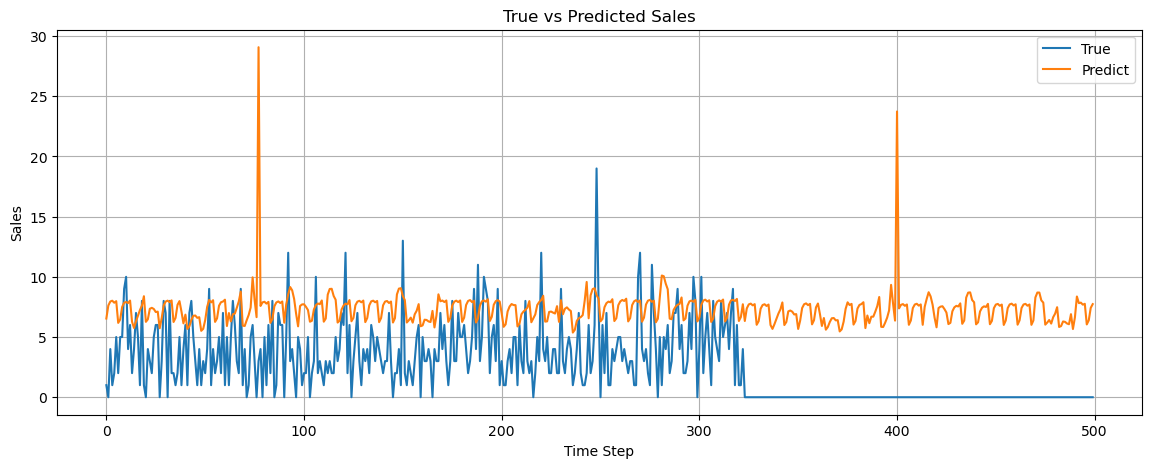

In [24]:
sample_n = 500

plt.figure(figsize=(14,5))
plt.plot(range(sample_n), results_df["y_true"].values[:sample_n], label="True")
plt.plot(range(sample_n), results_df["y_preds"].values[:sample_n], label="Predict")

plt.title("True vs Predicted Sales")
plt.xlabel("Time Step")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

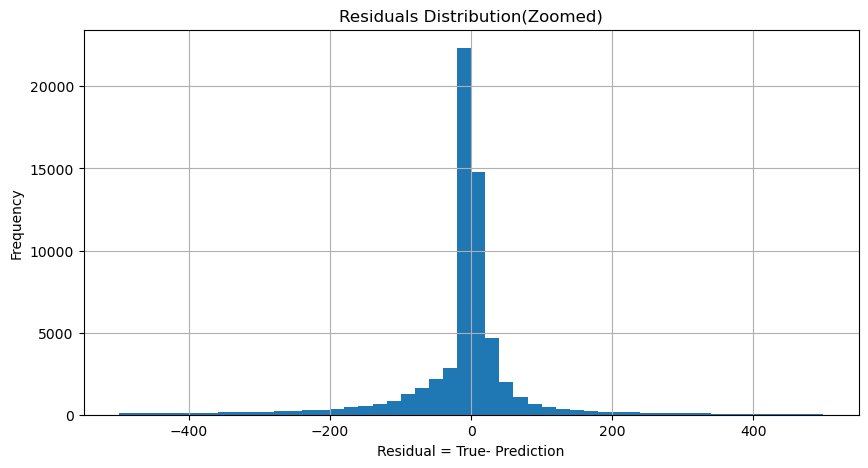

In [26]:
plt.figure(figsize=(10,5))

filtered_residuals = results_df["residual"]
filtered_residuals = filtered_residuals[np.abs(filtered_residuals)<500]

plt.hist(filtered_residuals, bins=50)
plt.title("Residuals Distribution(Zoomed)")
plt.xlabel("Residual = True- Prediction")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

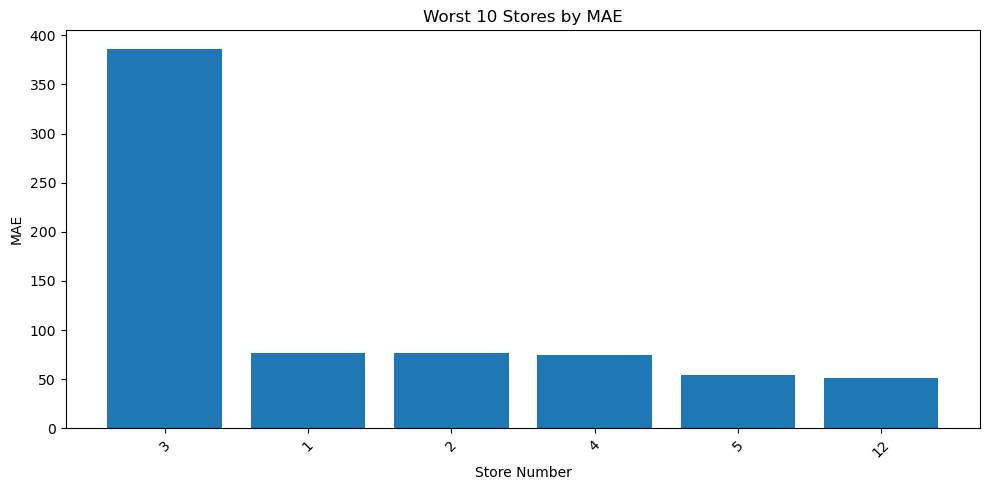

In [27]:
worst_stores = store_metrics.head(10)
plt.figure(figsize=(10,5))
plt.bar(worst_stores.index.astype(str), worst_stores["MAE"].values)
plt.title("Worst 10 Stores by MAE")
plt.xlabel("Store Number")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

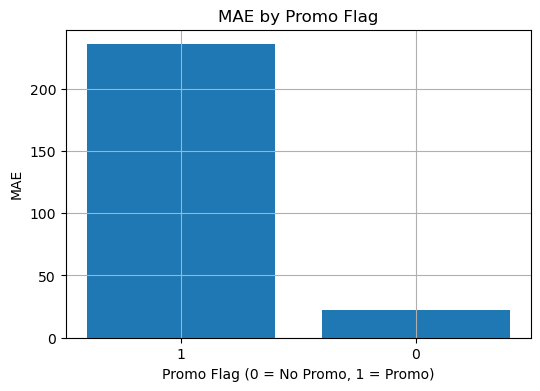

In [28]:
plt.figure(figsize=(6,4))
plt.bar(promo_metrics.index.astype(str), promo_metrics["MAE"].values)
plt.title("MAE by Promo Flag")
plt.xlabel("Promo Flag (0 = No Promo, 1 = Promo)")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

In [29]:
import joblib

lstm_model.save("../outputs/lstm_model.h5")
joblib.dump(seq_scaler, "../outputs/seq_scaler.pkl")

results_df.to_csv("../outputs/lstm_predictions.csv", index=False)

pd.DataFrame([{
    "rmse": lstm_rmse,
    "mae": lstm_mae,
    "mape": lstm_mape
}]).to_csv("../outputs/lstm_metrics.csv", index=False)

store_metrics.to_csv("../outputs/lstm_store_metrics.csv", index=True)
family_metrics.to_csv("../outputs/lstm_family_metrics.csv", index=True)
promo_metrics.to_csv("../outputs/lstm_promo_metrics.csv", index=True)

pd.DataFrame(history_lstm.history).to_csv("../outputs/lstm_history.csv", index=False)
plt.savefig("../outputs/figures/lstm_loss.png", bbox_inches="tight")

plt.savefig("../outputs/figures/lstm_true_vs_pred.png", bbox_inches="tight")
plt.savefig("../outputs/figures/lstm_residual_hist.png", bbox_inches="tight")
plt.savefig("../outputs/figures/lstm_worst_stores_mae.png", bbox_inches="tight")
plt.savefig("../outputs/figures/lstm_promo_mae.png", bbox_inches="tight")



<Figure size 640x480 with 0 Axes>